In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize pixel values
x_train, x_test = x_train / 255.0, x_test / 255.0

# Reshape for CNN (add channel dimension)
x_train = x_train.reshape((-1, 28, 28, 1))
x_test = x_test.reshape((-1, 28, 28, 1))

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


### MNIST Dataset Visualization
The following figure shows sample images from the MNIST training dataset after normalization and reshaping. This step helps verify that the data is correctly loaded and formatted before training the CNN model.


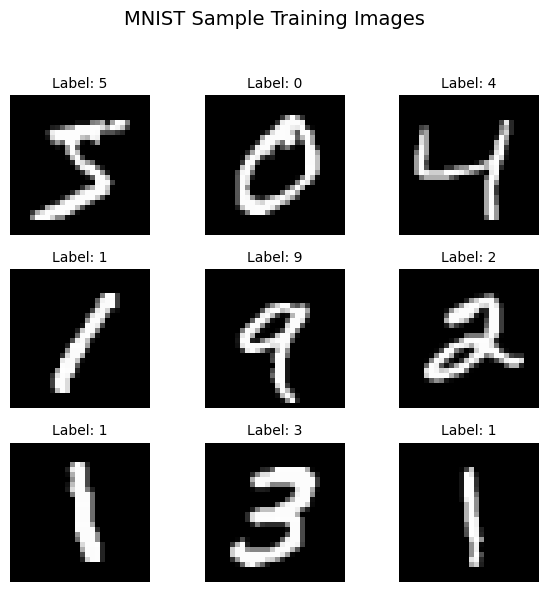

In [3]:
plt.figure(figsize=(6,6))
plt.suptitle("MNIST Sample Training Images", fontsize=14)

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(f"Label: {y_train[i]}", fontsize=10)
    plt.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Step 3: Train a Simple CNN Model
In this step, I define a Convolutional Neural Network (CNN) to classify handwritten digits (0–9). CNNs work well for image data because they can detect patterns like edges, curves, and shapes. The model is compiled using Adam optimizer and trained for 5 epochs.

In [4]:
import tensorflow as tf

# Step 3: Define the CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Show model architecture
model.summary()

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9124 - loss: 0.2949 - val_accuracy: 0.9797 - val_loss: 0.0642
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9827 - loss: 0.0563 - val_accuracy: 0.9833 - val_loss: 0.0490
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9901 - loss: 0.0320 - val_accuracy: 0.9875 - val_loss: 0.0405
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 20ms/step - accuracy: 0.9937 - loss: 0.0197 - val_accuracy: 0.9881 - val_loss: 0.0392
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.9964 - loss: 0.0122 - val_accuracy: 0.9866 - val_loss: 0.0447


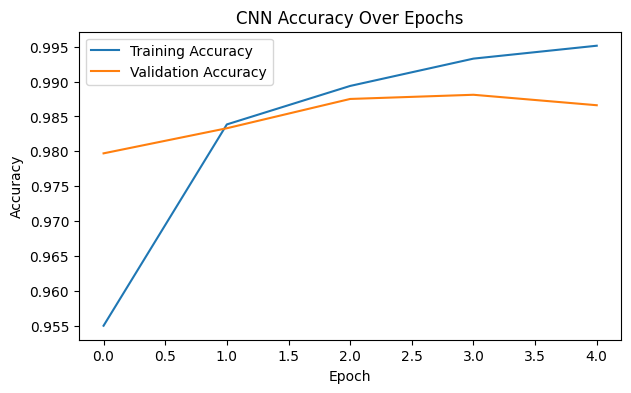

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("CNN Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [6]:
# Step 4: Convert the trained model to TensorFlow Lite

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the .tflite model
with open("model.tflite", "wb") as f:
    f.write(tflite_model)

print("✅ Model converted and saved as model.tflite")
print("TFLite model size (bytes):", len(tflite_model))


Saved artifact at '/tmp/tmpdytqmwze'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136308667645392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136308667645584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136308667644432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136308667643856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136308667645776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136308667645200: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Model converted and saved as model.tflite
TFLite model size (bytes): 2778584


### Step 5: TensorFlow Lite Inference and Latency Evaluation
This step validates the converted TFLite model by running inference on test images and measuring average latency to simulate edge-device performance.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input details: [{'name': 'serving_default_keras_tensor:0', 'index': 0, 'shape': array([ 1, 28, 28,  1], dtype=int32), 'shape_signature': array([-1, 28, 28,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 13, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([-1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]


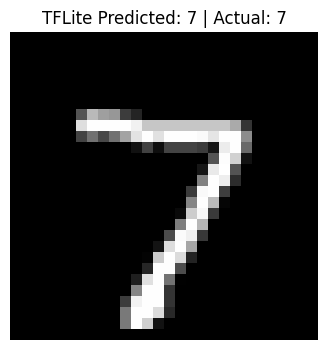

Raw probabilities: [[5.8039535e-11 4.3256981e-10 1.5901679e-09 2.0151333e-08 1.7796942e-10
  1.6165680e-10 1.4168862e-14 1.0000000e+00 3.3327807e-09 8.9736725e-09]]


In [7]:
# Step 5: Load and test the converted model using TFLite Interpreter

interpreter = tf.lite.Interpreter(model_path="model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input details:", input_details)
print("Output details:", output_details)

# Pick one test image
idx = 0
test_image = x_test[idx].astype("float32")          # shape (28,28,1)
test_image = np.expand_dims(test_image, axis=0)     # shape (1,28,28,1)

# Set input tensor
interpreter.set_tensor(input_details[0]["index"], test_image)

# Run inference
interpreter.invoke()

# Get output tensor (probabilities)
output_data = interpreter.get_tensor(output_details[0]["index"])
predicted_label = np.argmax(output_data)

# Display
plt.figure(figsize=(4,4))
plt.imshow(x_test[idx].reshape(28,28), cmap="gray")
plt.title(f"TFLite Predicted: {predicted_label} | Actual: {y_test[idx]}")
plt.axis("off")
plt.show()

print("Raw probabilities:", output_data)


In [8]:
import time

runs = 50
start = time.time()
for _ in range(runs):
    interpreter.set_tensor(input_details[0]["index"], test_image)
    interpreter.invoke()
end = time.time()

avg_ms = ((end - start) / runs) * 1000
print(f"✅ Average inference latency over {runs} runs: {avg_ms:.2f} ms")


✅ Average inference latency over 50 runs: 0.38 ms
